# 14 — Relapse: new lesions or reactivated old ones?

At a relapse (PEAK2, PEAK2_MILD, PEAK3) the spinal cord already carries tissue from the first attack. Notebook 10's
lesion states separate **active** tissue (S1 monocyte-derived myeloid; S4 monocyte-derived + oligodendrocyte damage)
from **old/late** tissue (S2 fibrosis + myelinating-oligodendrocyte loss) and glial-reactive tissue (S0). Question:
do relapse lesions grow out of old lesions (active tissue next to / inside S2 tissue) or appear in fresh tissue?

- **A.** Adjacency of active to old tissue, against a within-piece permutation null (state labels shuffled among
  the piece's lesion cells, so lesion geometry and state shares are kept). The **first attack** (RR and chronic
  PEAK1, no earlier lesions) gives the reference for how much active–S2 contact the disease produces without any
  history.
- **B.** Lesion objects (lesion cells linked within 30 µm in a piece): share of active tissue in objects that also
  hold old tissue.
- **C.** Where active relapse tissue sits (WM / GM / meninges).
- **D.** B-cell aggregates (≥ 5 B cells among a B cell's 15 nearest cells): near active or old tissue?
- **E.** Astrocyte vimentin (images, within-image z) at the active/old interface vs inside each.
- **F.** Maps of representative pieces.

All spatial work is within a tissue piece (`meta_sample_id`). Unit = animal. Cross-sectional data: an "old" state at
a relapse may also have formed during the same attack; the first-attack reference is what guards against that.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, wilcoxon

from beyondboundaries import plotting

plotting.style()
SRC = "notebooks/14_relapse_lesion_origin.ipynb"
OUT = ROOT / "results" / "14_relapse_lesion_origin"
OUT.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(0)
COL = plotting.CATEGORICAL

a = ad.read_h5ad(ROOT / "data" / "RRMAP2_all_runs.h5ad", backed="r")
obs = a.obs[["sample_name", "meta_sample_id", "sample_id", "stage", "model", "x_centroid", "y_centroid"]].copy()
a.file.close()
obs = obs.join(pd.read_parquet(ROOT / "data" / "lesion10" / "lesion_calls.parquet"))
obs["stage"] = obs.stage.astype(str)
obs["arm"] = np.where(obs.model.astype(str).str.startswith("CHRONIC"), "chronic", "RR")
ls = obs.lesion_state.astype(str)
obs["kind"] = np.select([ls.str.startswith("S1:") | ls.str.startswith("S4:"), ls.str.startswith("S2:"),
                         ls.str.startswith("S0:"), ls.str.startswith("S")], ["active", "old", "glial", "other lesion"],
                        "no lesion")
obs.loc[obs.region_class == "other", "kind"] = "not scored"
GROUPS = {"first attack": (obs.stage == "PEAK1"), "relapse": obs.stage.isin(["PEAK2", "PEAK2_MILD", "PEAK3"])}
obs["course"] = np.select(list(GROUPS.values()), list(GROUPS), "other")
print({s: sorted(set(obs.loc[obs.lesion_state.str.startswith(s), "lesion_state"]))[0] for s in ["S0", "S1", "S2", "S4"]})
animals = obs[obs.course != "other"].groupby("sample_name", observed=True).agg(
    course=("course", "first"), arm=("arm", "first"), stage=("stage", "first"))
animals.groupby(["course", "arm", "stage"]).size()

{'S0': 'S0: astro reactivity + oligo disease state', 'S1': 'S1: monocyte-derived myeloid + microglia homeostasis loss', 'S2': 'S2: fibrosis + myelinating oligo loss', 'S4': 'S4: monocyte-derived myeloid + oligo disease state'}


course        arm      stage     
first attack  RR       PEAK1         4
              chronic  PEAK1         6
relapse       RR       PEAK2         2
                       PEAK2_MILD    2
                       PEAK3         5
dtype: int64

## A. Is active tissue next to old tissue more than expected?
Per animal: share of active cells with an old (S2) cell within 50 µm in the same piece, observed and under the
permutation null (state labels shuffled among the piece's lesion cells, 30 permutations); enrichment = observed ÷
expected.

In [2]:
R_ADJ = 50.0
NPERM = 30
rows, dist_rows = [], []
for pc, g in obs[(obs.course != "other") & obs.kind.isin(["active", "old", "glial", "other lesion"])].groupby(
        "meta_sample_id", observed=True):
    kind = g.kind.to_numpy()
    xy = g[["x_centroid", "y_centroid"]].to_numpy()
    act, old = kind == "active", kind == "old"
    if act.sum() < 50:
        continue
    tree = cKDTree(xy)
    nbrs = tree.query_ball_point(xy[act], R_ADJ)

    def adj_share(is_old, nbrs=nbrs):
        return np.mean([is_old[n].any() for n in nbrs])

    obs_adj = adj_share(old) if old.any() else 0.0
    exp = []
    for _ in range(NPERM):
        perm = rng.permutation(kind)
        nb = tree.query_ball_point(xy[perm == "active"], R_ADJ)
        exp.append(adj_share(perm == "old", nb) if (perm == "old").any() else 0.0)
    d_old = cKDTree(xy[old]).query(xy[act], k=1)[0] if old.any() else np.full(act.sum(), np.inf)
    rows.append(dict(piece=pc, sample_name=g.sample_name.iloc[0], course=g.course.iloc[0], n_active=int(act.sum()),
                     n_old=int(old.sum()), old_share=old.mean(), adj_obs=obs_adj, adj_exp=np.mean(exp),
                     median_dist_active_to_old=np.median(d_old)))
pcs = pd.DataFrame(rows)
# per animal: cell-weighted over its pieces
an = pcs.groupby("sample_name").apply(lambda g: pd.Series({
    "course": g.course.iloc[0], "n_active": g.n_active.sum(), "old_share": np.average(g.old_share, weights=g.n_active),
    "adj_obs": np.average(g.adj_obs, weights=g.n_active), "adj_exp": np.average(g.adj_exp, weights=g.n_active),
    "median_dist_active_to_old": np.average(np.minimum(g.median_dist_active_to_old, 5000), weights=g.n_active)}),
    include_groups=False).join(animals[["arm", "stage"]])
an["enrichment"] = an.adj_obs / an.adj_exp
an.to_csv(OUT / "A_adjacency_per_animal.csv")
an.groupby("course")[["old_share", "adj_obs", "adj_exp", "enrichment", "median_dist_active_to_old"]].median().round(3)

,old_share,adj_obs,adj_exp,enrichment,median_dist_active_to_old
course,,,,,
first attack,0.017,0.050,0.417,0.139,264.686
relapse,0.079,0.234,0.848,0.328,101.465


old_share: first attack 0.017 (n=10) vs relapse 0.079 (n=9), MWU p = 0.000944
adj_obs: first attack 0.050 (n=10) vs relapse 0.234 (n=9), MWU p = 0.000383
enrichment: first attack 0.139 (n=10) vs relapse 0.328 (n=9), MWU p = 0.000944
median_dist_active_to_old: first attack 264.686 (n=10) vs relapse 101.465 (n=9), MWU p = 0.00052


PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/14_relapse_lesion_origin/A_adjacency.png')

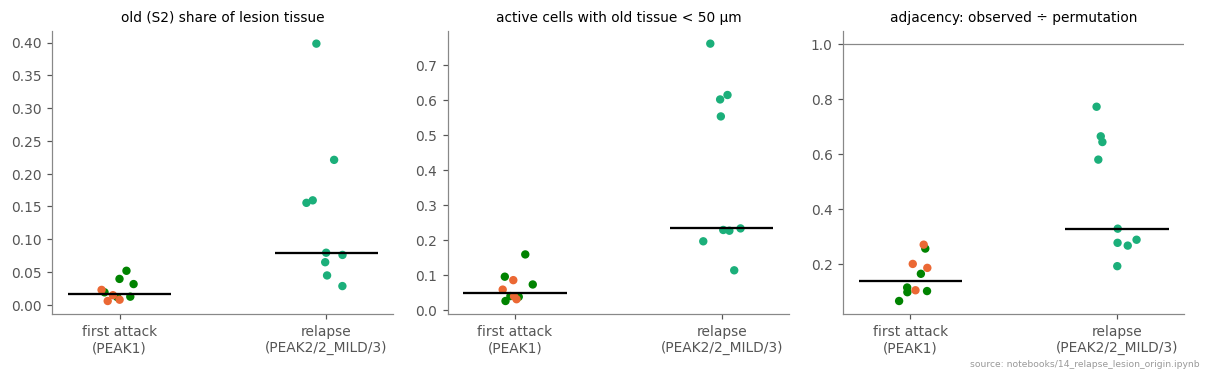

In [3]:
f, r = an[an.course == "first attack"], an[an.course == "relapse"]
for c in ["old_share", "adj_obs", "enrichment", "median_dist_active_to_old"]:
    print(f"{c}: first attack {f[c].median():.3f} (n={len(f)}) vs relapse {r[c].median():.3f} (n={len(r)}), "
          f"MWU p = {mannwhitneyu(f[c], r[c]).pvalue:.3g}")
fig, axs = plt.subplots(1, 3, figsize=(11, 3.4))
for ax, c, lab in zip(axs, ["old_share", "adj_obs", "enrichment"],
                      ["old (S2) share of lesion tissue", f"active cells with old tissue < {R_ADJ:.0f} µm",
                       "adjacency: observed ÷ permutation"]):
    for k, crs in enumerate(["first attack", "relapse"]):
        d = an[an.course == crs]
        ax.scatter(np.full(len(d), k) + rng.uniform(-0.1, 0.1, len(d)), d[c], s=20,
                   color=[COL[1] if s == "PEAK1" and a_ == "RR" else COL[5] if s == "PEAK1" else COL[2]
                          for s, a_ in zip(d.stage, d.arm)])
        ax.hlines(d[c].median(), k - 0.25, k + 0.25, color="black", lw=1.5)
    ax.set_xticks([0, 1], ["first attack\n(PEAK1)", "relapse\n(PEAK2/2_MILD/3)"]); ax.set_title(lab, fontsize=9)
axs[2].axhline(1, color="#888888", lw=0.8)
fig.tight_layout()
plotting.save_fig(fig, "A_adjacency", OUT, SRC)

## B. Lesion objects
Lesion cells linked when < 30 µm apart (same piece); objects ≥ 50 cells. Per animal: share of active cells in objects
that also contain ≥ 10 % old tissue ("mixed" objects), and object counts.

In [4]:
rows = []
for pc, g in obs[(obs.course != "other") & obs.kind.isin(["active", "old", "glial", "other lesion"])].groupby(
        "meta_sample_id", observed=True):
    xy = g[["x_centroid", "y_centroid"]].to_numpy()
    pairs = cKDTree(xy).query_pairs(30.0, output_type="ndarray")
    A = coo_matrix((np.ones(len(pairs)), (pairs[:, 0], pairs[:, 1])), shape=(len(g), len(g)))
    _, lab = connected_components(A, directed=False)
    o = pd.DataFrame({"obj": lab, "kind": g.kind.to_numpy()})
    stats = o.groupby("obj").kind.agg(size="size", old=lambda s: (s == "old").mean(), active=lambda s: (s == "active").mean())
    stats = stats[stats["size"] >= 50]
    for ob, s in stats.iterrows():
        rows.append(dict(piece=pc, sample_name=g.sample_name.iloc[0], course=g.course.iloc[0], obj=ob, size=s["size"],
                         old=s.old, active=s.active))
objs = pd.DataFrame(rows)
objs["n_active"] = objs["size"] * objs.active
objs["mixed"] = (objs.old >= 0.10) & (objs.active >= 0.10)
ob_an = objs.groupby("sample_name").apply(lambda g: pd.Series({
    "objects": len(g), "median object size": g["size"].median(),
    "active in mixed objects": g.loc[g.mixed, "n_active"].sum() / max(g.n_active.sum(), 1)}),
    include_groups=False).join(animals[["course", "arm", "stage"]])
ob_an.to_csv(OUT / "B_objects_per_animal.csv")
print({c: f"first {ob_an[ob_an.course == 'first attack'][c].median():.3f} vs relapse "
          f"{ob_an[ob_an.course == 'relapse'][c].median():.3f}, p = "
          f"{mannwhitneyu(ob_an[ob_an.course == 'first attack'][c], ob_an[ob_an.course == 'relapse'][c]).pvalue:.3g}"
       for c in ["objects", "median object size", "active in mixed objects"]})
ob_an.groupby("course")[["objects", "median object size", "active in mixed objects"]].median().round(3)

{'objects': 'first 8.000 vs relapse 17.000, p = 0.0125', 'median object size': 'first 266.750 vs relapse 219.000, p = 0.54', 'active in mixed objects': 'first 0.000 vs relapse 0.189, p = 0.00169'}


,objects,median object size,active in mixed objects
course,,,
first attack,8.0,266.75,0.000
relapse,17.0,219.00,0.189


## C. Where active tissue sits

In [5]:
act = obs[(obs.kind == "active") & (obs.course != "other")]
where = pd.crosstab(act.sample_name, act.region_class, normalize="index").join(animals[["course", "arm"]])
where.to_csv(OUT / "C_active_location_per_animal.csv")
where.groupby(["course", "arm"])[["WM", "GM", "meninges"]].median().round(3)

WM     GM  meninges
course       arm                            
first attack RR       0.947  0.047     0.006
             chronic  0.956  0.030     0.016
relapse      RR       0.948  0.024     0.025

## D. B-cell aggregates: next to active or old tissue?
B cells with ≥ 5 B cells among their 15 nearest cells (same piece). Per animal: median distance from active cells and
from old cells to the nearest aggregated B cell, and the share of aggregated B cells with active vs old tissue
within 50 µm.

In [6]:
rows = []
for pc, g in obs[obs.course != "other"].groupby("meta_sample_id", observed=True):
    isb = (g.ctype == "B cell").to_numpy()
    if isb.sum() < 5:
        continue
    xy = g[["x_centroid", "y_centroid"]].to_numpy()
    _, nn = cKDTree(xy).query(xy[isb], k=16)
    aggB = xy[isb][isb[nn[:, 1:]].sum(1) >= 5]
    if len(aggB) == 0:
        continue
    kind = g.kind.to_numpy()
    tb = cKDTree(aggB)
    near = {}
    for kd in ["active", "old"]:
        m = kind == kd
        near[kd] = tb.query(xy[m], k=1)[0] if m.any() else np.array([])
        near[f"B_{kd}"] = (cKDTree(xy[m]).query(aggB, k=1)[0] < 50).mean() if m.any() else np.nan
    rows.append(dict(piece=pc, sample_name=g.sample_name.iloc[0], n_aggB=len(aggB),
                     d_active=np.median(near["active"]) if len(near["active"]) else np.nan,
                     d_old=np.median(near["old"]) if len(near["old"]) else np.nan,
                     aggB_near_active=near["B_active"], aggB_near_old=near["B_old"],
                     aggB_meningeal=(g.region_class.to_numpy()[isb][isb[nn[:, 1:]].sum(1) >= 5] == "meninges").mean()))
bp = pd.DataFrame(rows)
bagg = bp.groupby("sample_name").apply(lambda g: pd.Series({
    "aggregated B cells": g.n_aggB.sum(),
    **{c: np.average(g[c].fillna(g[c].median() if g[c].notna().any() else 0), weights=g.n_aggB)
       for c in ["d_active", "d_old", "aggB_near_active", "aggB_near_old", "aggB_meningeal"]}}),
    include_groups=False).join(animals[["course", "arm", "stage"]])
bagg.to_csv(OUT / "D_b_aggregates_per_animal.csv")
for crs, d in bagg.groupby("course"):
    d = d[d["aggregated B cells"] >= 10]
    if len(d) >= 3:
        print(f"{crs} (n={len(d)}): aggregated B near active {d.aggB_near_active.median():.2f}, near old "
              f"{d.aggB_near_old.median():.2f}, meningeal {d.aggB_meningeal.median():.2f}; "
              f"median distance active→agg {d.d_active.median():.0f} µm vs old→agg {d.d_old.median():.0f} µm "
              f"(paired Wilcoxon p = {wilcoxon(d.d_active - d.d_old).pvalue if len(d) >= 5 else np.nan:.3g})")
bagg.groupby("course")[["aggregated B cells", "aggB_near_active", "aggB_near_old", "aggB_meningeal",
                        "d_active", "d_old"]].median().round(2)

first attack (n=6): aggregated B near active 1.00, near old 0.31, meningeal 0.05; median distance active→agg 373 µm vs old→agg 494 µm (paired Wilcoxon p = 0.688)
relapse (n=9): aggregated B near active 0.89, near old 0.72, meningeal 0.33; median distance active→agg 281 µm vs old→agg 350 µm (paired Wilcoxon p = 0.129)


,aggregated B cells,aggB_near_active,aggB_near_old,aggB_meningeal,d_active,d_old
course,,,,,,
first attack,118.0,1.00,0.31,0.05,373.03,493.64
relapse,349.0,0.89,0.72,0.33,281.45,350.06


## E. Astrocyte vimentin at the active/old interface
18S-segmented astrocytes inside lesions, image features (cells < 20 µm from another piece excluded). Zone by the
lesion states within 30 µm: **interface** (active and old cells both within 30 µm), **active** (active only), **old**
(old only). Vimentin-channel cell mean, robust z within image (astrocytes). Per animal median per zone; paired
comparisons within animal.

In [7]:
fa = pd.read_parquet(ROOT / "data" / "features_norm_all.parquet",
                     columns=["section_id", "meta_sample_id", "Anno_L1_curated", "segmentation_method", "x_centroid",
                              "y_centroid", "smavim_cell_mean"])
fa = fa[(fa.Anno_L1_curated == "Astrocyte") & (fa.segmentation_method == "Segmented by interior stain (18S)")]
fa = fa.join(obs[["kind", "course", "sample_name"]], how="inner")
med = fa.smavim_cell_mean.groupby(fa.section_id, observed=True).transform("median")
mad = (fa.smavim_cell_mean - med).abs().groupby(fa.section_id, observed=True).transform("median") * 1.4826
fa["vim_z"] = (fa.smavim_cell_mean - med) / mad.replace(0, np.nan)
rows = []
for pc, g in obs[obs.course != "other"].groupby("meta_sample_id", observed=True):
    ast = fa[(fa.meta_sample_id == pc) & fa.kind.isin(["active", "old", "glial", "other lesion"])]
    if len(ast) < 20:
        continue
    # other-piece exclusion
    sec = obs[obs.sample_id == g.sample_id.iloc[0]]
    oth = sec[sec.meta_sample_id != pc]
    d_oth = cKDTree(oth[["x_centroid", "y_centroid"]].to_numpy()).query(ast[["x_centroid", "y_centroid"]].to_numpy())[0] \
        if len(oth) else np.full(len(ast), np.inf)
    ast = ast[d_oth >= 20]
    kind = g.kind.to_numpy()
    xy = g[["x_centroid", "y_centroid"]].to_numpy()
    flags = {}
    for kd in ["active", "old"]:
        m = kind == kd
        flags[kd] = (cKDTree(xy[m]).query(ast[["x_centroid", "y_centroid"]].to_numpy())[0] < 30) if m.any() \
            else np.zeros(len(ast), bool)
    zone = np.select([flags["active"] & flags["old"], flags["active"], flags["old"]], ["interface", "active", "old"],
                     "neither")
    rows.append(pd.DataFrame({"sample_name": g.sample_name.iloc[0], "zone": zone, "vim_z": ast.vim_z.to_numpy()}))
vz = pd.concat(rows)
vz_an = vz.groupby(["sample_name", "zone"]).vim_z.agg(["median", "size"])
vz_an = vz_an[vz_an["size"] >= 20]["median"].unstack().join(animals[["course", "arm", "stage"]])
vz_an.to_csv(OUT / "E_vimentin_by_zone_per_animal.csv")
for crs, d in vz_an.groupby("course"):
    for a_, b_ in [("interface", "active"), ("interface", "old"), ("old", "active")]:
        x = d[[a_, b_]].dropna()
        if len(x) >= 5:
            print(f"{crs}: {a_} {x[a_].median():.2f} vs {b_} {x[b_].median():.2f} (n={len(x)}, paired Wilcoxon p = "
                  f"{wilcoxon(x[a_] - x[b_]).pvalue:.3g})")
vz_an.groupby("course")[["active", "interface", "old", "neither"]].median().round(2)

first attack: interface 4.01 vs active 4.78 (n=9, paired Wilcoxon p = 0.164)
first attack: interface 4.01 vs old 3.91 (n=9, paired Wilcoxon p = 0.25)
first attack: old 3.62 vs active 3.63 (n=10, paired Wilcoxon p = 0.557)
relapse: interface 1.72 vs active 2.21 (n=9, paired Wilcoxon p = 0.652)
relapse: interface 1.72 vs old 1.93 (n=9, paired Wilcoxon p = 0.164)
relapse: old 1.93 vs active 2.21 (n=9, paired Wilcoxon p = 0.359)


,active,interface,old,neither
course,,,,
first attack,3.63,4.01,3.62,0.04
relapse,2.21,1.72,1.93,-0.07


## F. Maps
Three relapse pieces with the most active *and* old tissue (largest min(active, old) cell count; not chosen by
appearance) and one first-attack piece for comparison. Grey = no lesion; orange = active (S1/S4); blue = old (S2);
green = glial (S0); black dots = aggregated B cells.

PosixPath('/Users/christoffer/work/karolinska/development/BeyondBoundaries/results/14_relapse_lesion_origin/F_maps.png')

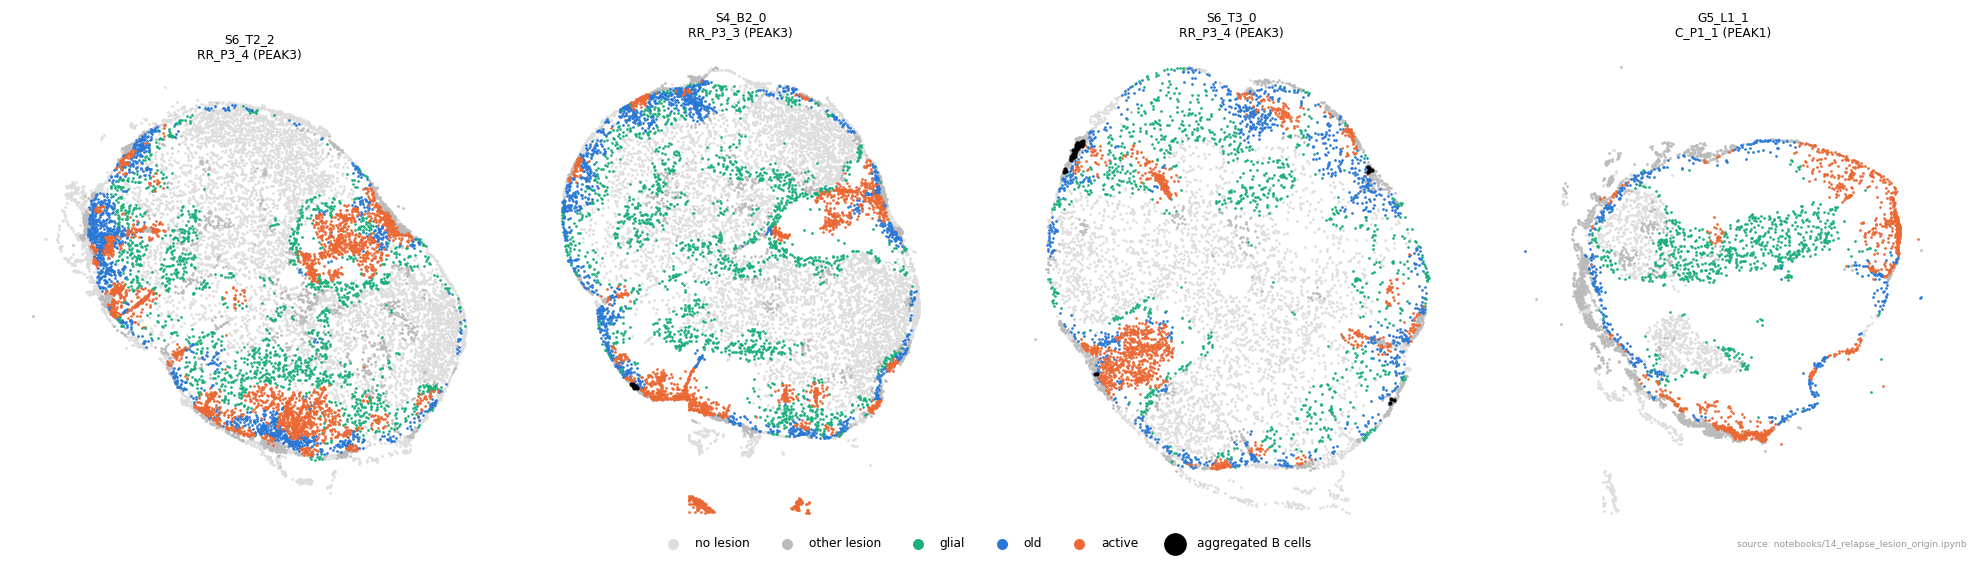

In [8]:
cnt = obs[obs.course != "other"].groupby(["meta_sample_id", "course"], observed=True).kind.agg(
    act=lambda s: (s == "active").sum(), old=lambda s: (s == "old").sum()).reset_index()
cnt["m"] = cnt[["act", "old"]].min(1)
pick = (cnt[cnt.course == "relapse"].nlargest(3, "m").meta_sample_id.tolist()
        + cnt[cnt.course == "first attack"].nlargest(1, "m").meta_sample_id.tolist())
KC = {"no lesion": "#dddddd", "other lesion": "#bbbbbb", "glial": COL[2], "old": COL[0], "active": COL[1]}
fig, axs = plt.subplots(1, 4, figsize=(18, 5))
for ax, pc in zip(axs, pick):
    g = obs[(obs.meta_sample_id == pc) & (obs.region_class != "other")]
    for kd in ["no lesion", "other lesion", "glial", "old", "active"]:
        m = g.kind == kd
        ax.scatter(g.x_centroid[m], -g.y_centroid[m], s=0.6, color=KC[kd], rasterized=True,
                   label=kd if pc == pick[0] else None)
    isb = (g.ctype == "B cell").to_numpy()
    if isb.sum() >= 5:
        xy = g[["x_centroid", "y_centroid"]].to_numpy()
        _, nn = cKDTree(xy).query(xy[isb], k=16)
        ag = xy[isb][isb[nn[:, 1:]].sum(1) >= 5]
        ax.scatter(ag[:, 0], -ag[:, 1], s=3, color="black", label="aggregated B cells" if pc == pick[0] else None)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(f"{pc}\n{g.sample_name.iloc[0]} ({g.stage.iloc[0]})", fontsize=8)
fig.legend(markerscale=8, fontsize=8, loc="lower center", ncol=6, bbox_to_anchor=(0.5, -0.02))
fig.tight_layout()
plotting.save_fig(fig, "F_maps", OUT, SRC)

## Findings

> **Finding — relapse lesions partly grow at the edge of old lesions.** At relapse, active tissue (S1/S4) is in contact
> with old fibrotic tissue (S2) far more than at the first attack: active cells with old tissue within 50 µm 0.23 vs
> 0.05 (9 vs 10 animals, p = 4e-4); median distance active → old 101 vs 265 µm (p = 5e-4). This holds against the
> within-piece permutation null, which keeps each piece's old-tissue share (enrichment 0.33 vs 0.14, p = 9e-4). In
> both courses enrichment stays < 1: active and old tissue form separate patches that touch at their borders rather
> than intermixing.
>
> **Finding — but most relapse activity is in separate lesion objects.** Relapse animals have twice as many lesion
> objects (17 vs 8, p = 0.01). 19 % of active relapse tissue lies in objects that also contain ≥ 10 % old tissue
> (first attack 0 %, p = 0.002); the other ~80 % is in objects without old tissue. Active tissue is ~95 % white matter
> in both courses (meninges 2.5 % vs 0.6–1.6 %). So a relapse is a mix of reactivation at old lesion borders and new
> white-matter lesions.
>
> **Finding — B-cell aggregates move towards old tissue and the meninges at relapse.** Share of aggregated B cells
> with old tissue within 50 µm: 0.72 vs 0.31 at the first attack; meningeal share 0.33 vs 0.05 (9 vs 6 animals with
> ≥ 10 aggregated B cells). Nearly all aggregates sit next to active tissue in both courses (0.89–1.00), so the
> aggregates are at the active/old border at relapse.
>
> **Finding — no vimentin signature of the interface.** Lesion astrocyte vimentin does not differ between active,
> old and interface zones within animals (paired p ≥ 0.16). Relapse lesions as a whole are lower than first-attack
> lesions (median z ~2 vs ~3.6–4.0).
>
> Caveats: cross-sectional, so "old" means the S2 state, not a known age. S2 exists in small amounts at the first
> attack too (1.7 % of lesion tissue, often along the pial rim; map, right), and part of the relapse S2 may have formed
> during the same attack. The first-attack comparison and the permutation null are the guards. Relapse animals come
> from runs 2, 3, 5, 6 and first-attack animals from runs 1, 2, 3, 5, 6; all measures are within piece.